# 🧮 Complex Vector Spaces & Matrix Operations
### MSE Programme — Student Notebook
**Effective from May 2026 · Quantum Computing Foundations**

---
> *"Quantum theory is cast in the language of complex vector spaces."*

This notebook takes you step-by-step through the mathematics you need to understand quantum simulations. No heavy prior math background required — just follow along, run each cell, and experiment!

### 📚 Contents
1. Complex Numbers — Quick Refresher  
2. Vectors in Cⁿ — The Building Blocks  
3. Vector Operations — Addition & Scalar Multiplication  
4. Matrices & Key Operations  
5. Types of Matrices for Quantum Computing  
6. Inner Products & Norms  
7. Hermitian Matrices  
8. Unitary Matrices  
9. Tensor Products & Entanglement  
10. Mini Exercises

---


## ⚙️ Setup — Run This First
We'll use `numpy` for all matrix and vector operations. Run the cell below before anything else.

In [15]:
import numpy as np

# Pretty-print helper for complex vectors/matrices
def show(label, arr):
    print(f"{'─'*40}")
    print(f"  {label}:")
    print(f"{'─'*40}")
    if arr.ndim == 1:
        for i, v in enumerate(arr):
            print(f"  [{i}]  {v}")
    else:
        for row in arr:
            print("  ", "  ".join(f"{v: >12}" for v in row))
    print()

print("✅ Setup complete. NumPy version:", np.__version__)


✅ Setup complete. NumPy version: 2.4.4


---
## 1. Complex Numbers — Quick Refresher

A **complex number** has the form `a + bj`, where:
- `a` = real part
- `b` = imaginary part  
- `j` = √(−1)  *(Python uses `j` instead of `i`)*

**Why do we need them?** Real numbers can't describe the *phase* of a quantum state. Complex numbers can — and phase is what makes quantum interference possible.


In [16]:
# Basic complex number arithmetic
z1 = 3 + 2j
z2 = 1 - 4j

print("z1 =", z1)
print("z2 =", z2)
print()
print("Addition:        z1 + z2 =", z1 + z2)
print("Subtraction:     z1 - z2 =", z1 - z2)
print("Multiplication:  z1 * z2 =", z1 * z2)
print()
print("Real part of z1:      ", z1.real)
print("Imaginary part of z1: ", z1.imag)
print("Complex conjugate z1*:", z1.conjugate())
print("Modulus |z1|:         ", abs(z1))


z1 = (3+2j)
z2 = (1-4j)

Addition:        z1 + z2 = (4-2j)
Subtraction:     z1 - z2 = (2+6j)
Multiplication:  z1 * z2 = (11-10j)

Real part of z1:       3.0
Imaginary part of z1:  2.0
Complex conjugate z1*: (3-2j)
Modulus |z1|:          3.605551275463989


> 💡 **Key idea:** The **complex conjugate** of `a + bj` is `a − bj`. We flip the sign of the imaginary part. This is used everywhere in quantum math.

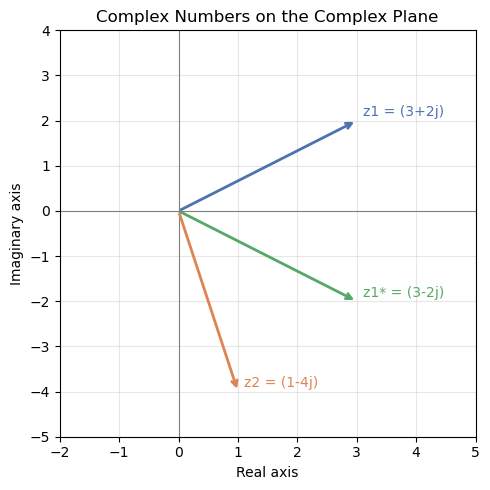

In [17]:
# Visualise complex numbers on the complex plane
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 5))
numbers = {'z1': 3+2j, 'z2': 1-4j, 'z1*': (3+2j).conjugate()}
colors  = ['#4C72B0', '#DD8452', '#55A868']

for (label, z), color in zip(numbers.items(), colors):
    ax.annotate('', xy=(z.real, z.imag), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=color, lw=2))
    ax.text(z.real + 0.1, z.imag + 0.1, f'{label} = {z}',
            fontsize=10, color=color)

ax.axhline(0, color='gray', linewidth=0.8)
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlim(-2, 5); ax.set_ylim(-5, 4)
ax.set_xlabel('Real axis'); ax.set_ylabel('Imaginary axis')
ax.set_title('Complex Numbers on the Complex Plane')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## 2. Vectors in Cⁿ — The Building Blocks

A **complex vector** is an ordered list of complex numbers. In quantum computing, vectors represent the **state** of a quantum system.

- **C²** — describes a single qubit (2 entries)
- **C⁴** — describes two qubits (4 entries)
- **C²ⁿ** — describes n qubits (2ⁿ entries)


In [18]:
# A vector in C⁴
V = np.array([6 - 4j,
              7 + 3j,
              4.2 - 8.1j,
              -3j])

show("V  (a vector in C⁴)", V)

# Indexing — note: Python is 0-indexed (first element is [0])
print("V[0] =", V[0])   # first entry
print("V[1] =", V[1])   # second entry


────────────────────────────────────────
  V  (a vector in C⁴):
────────────────────────────────────────
  [0]  (6-4j)
  [1]  (7+3j)
  [2]  (4.2-8.1j)
  [3]  (-0-3j)

V[0] = (6-4j)
V[1] = (7+3j)


> 📌 **Notation tip:** We often write vectors as a vertical column. In code, they're just 1D arrays. The transpose notation Vᵀ just means "write it as a column" — the values are identical.

---
## 3. Vector Operations

Two fundamental operations define how we work with vectors.

### 3a. Vector Addition
Add two vectors **entry by entry**. Both vectors must be the same length.


In [19]:
V = np.array([6 - 4j,  7 + 3j,  4.2 - 8.1j,  -3j])
W = np.array([16 + 2.3j, -7j,   6 + 0j,      -4j])

result = V + W

show("V", V)
show("W", W)
show("V + W", result)


────────────────────────────────────────
  V:
────────────────────────────────────────
  [0]  (6-4j)
  [1]  (7+3j)
  [2]  (4.2-8.1j)
  [3]  (-0-3j)

────────────────────────────────────────
  W:
────────────────────────────────────────
  [0]  (16+2.3j)
  [1]  (-0-7j)
  [2]  (6+0j)
  [3]  (-0-4j)

────────────────────────────────────────
  V + W:
────────────────────────────────────────
  [0]  (22-1.7000000000000002j)
  [1]  (7-4j)
  [2]  (10.2-8.1j)
  [3]  (-0-7j)



**Key properties of vector addition:**
| Property | Meaning |
|---|---|
| Commutative | V + W = W + V |
| Associative | (V + W) + X = V + (W + X) |
| Zero vector | V + **0** = V |
| Inverse | V + (−V) = **0** |


In [20]:
# Verify commutativity
print("V + W == W + V?", np.allclose(V + W, W + V))

# Zero vector
zero = np.zeros(4, dtype=complex)
print("V + zero == V?", np.allclose(V + zero, V))

# Additive inverse
print("V + (-V) == zero?", np.allclose(V + (-V), zero))


V + W == W + V? True
V + zero == V? True
V + (-V) == zero? True


### 3b. Scalar Multiplication
Multiply **every entry** of a vector by a single complex number (the scalar). Think of it as stretching or rotating the vector.

In [21]:
V = np.array([6 + 3j, 0 + 0j, 5 + 1j, 4 + 0j])
c = 3 + 2j  # scalar

result = c * V

show("V (original)", V)
print(f"Scalar c = {c}")
print()
show("c · V", result)


────────────────────────────────────────
  V (original):
────────────────────────────────────────
  [0]  (6+3j)
  [1]  0j
  [2]  (5+1j)
  [3]  (4+0j)

Scalar c = (3+2j)

────────────────────────────────────────
  c · V:
────────────────────────────────────────
  [0]  (12+21j)
  [1]  0j
  [2]  (13+13j)
  [3]  (12+8j)



In [22]:
# Verify scalar multiplication properties
c1, c2 = 3 + 2j, 1 - 1j
V = np.array([1+1j, 2-1j, 0+3j])

# Property: c1 * (c2 * V) == (c1 * c2) * V
lhs = c1 * (c2 * V)
rhs = (c1 * c2) * V
print("c1·(c2·V) == (c1×c2)·V ?", np.allclose(lhs, rhs))

# Property: c * (V + W) == c*V + c*W  (distributive)
W = np.array([3-2j, 1+0j, -1+1j])
c = 2 + 1j
print("c·(V+W) == c·V + c·W  ?", np.allclose(c*(V+W), c*V + c*W))


c1·(c2·V) == (c1×c2)·V ? True
c·(V+W) == c·V + c·W  ? True


---
## 4. Matrices & Key Operations

A **matrix** is a rectangular grid of numbers. In quantum computing, matrices represent **operations** (transformations) that we apply to quantum states.

Think of it this way:
- **Vector** = current quantum state
- **Matrix** = quantum gate (an operation on that state)
- **Matrix × Vector** = new quantum state after the gate


In [23]:
# Define two 3×3 complex matrices
A = np.array([[3+2j,  0,    5-6j],
              [1,     4+2j, 1j  ],
              [4-1j,  0,    4   ]])

B = np.array([[5,     2-1j,  6-4j],
              [0,     4+5j,  2   ],
              [7-4j,  2+7j,  0   ]])

show("Matrix A", A)
show("Matrix B", B)


────────────────────────────────────────
  Matrix A:
────────────────────────────────────────
         (3+2j)            0j        (5-6j)
         (1+0j)        (4+2j)            1j
         (4-1j)            0j        (4+0j)

────────────────────────────────────────
  Matrix B:
────────────────────────────────────────
         (5+0j)        (2-1j)        (6-4j)
             0j        (4+5j)        (2+0j)
         (7-4j)        (2+7j)            0j



### 4a. Transpose (Aᵀ)
Swap rows and columns. Entry at [row, col] moves to [col, row].

In [24]:
AT = A.T
show("A  (original)", A)
show("Aᵀ (transpose)", AT)

# Verify: (Aᵀ)ᵀ = A
print("(Aᵀ)ᵀ == A ?", np.allclose(AT.T, A))


────────────────────────────────────────
  A  (original):
────────────────────────────────────────
         (3+2j)            0j        (5-6j)
         (1+0j)        (4+2j)            1j
         (4-1j)            0j        (4+0j)

────────────────────────────────────────
  Aᵀ (transpose):
────────────────────────────────────────
         (3+2j)        (1+0j)        (4-1j)
             0j        (4+2j)            0j
         (5-6j)            1j        (4+0j)

(Aᵀ)ᵀ == A ? True


### 4b. Conjugate (Ā)
Flip the sign of every imaginary part. The real parts stay the same.

In [25]:
A_conj = np.conj(A)
show("A      (original)", A)
show("Ā  (conjugate)", A_conj)


────────────────────────────────────────
  A      (original):
────────────────────────────────────────
         (3+2j)            0j        (5-6j)
         (1+0j)        (4+2j)            1j
         (4-1j)            0j        (4+0j)

────────────────────────────────────────
  Ā  (conjugate):
────────────────────────────────────────
         (3-2j)           -0j        (5+6j)
         (1-0j)        (4-2j)           -1j
         (4+1j)           -0j        (4-0j)



### 4c. Adjoint / Dagger (A†)
The **most important operation in quantum computing**. Combine transpose + conjugate together. Also written A† or A-dagger.

In [26]:
A_dag = A.conj().T   # adjoint = conjugate transpose

show("A   (original)", A)
show("A†  (adjoint = conjugate transpose)", A_dag)

# Key property: (A†)† = A
print("(A†)† == A ?", np.allclose(A_dag.conj().T, A))

# Adjoint respects addition: (A + B)† = A† + B†
print("(A+B)† == A†+B† ?", np.allclose((A+B).conj().T, A.conj().T + B.conj().T))


────────────────────────────────────────
  A   (original):
────────────────────────────────────────
         (3+2j)            0j        (5-6j)
         (1+0j)        (4+2j)            1j
         (4-1j)            0j        (4+0j)

────────────────────────────────────────
  A†  (adjoint = conjugate transpose):
────────────────────────────────────────
         (3-2j)        (1-0j)        (4+1j)
            -0j        (4-2j)           -0j
         (5+6j)           -1j        (4-0j)

(A†)† == A ? True
(A+B)† == A†+B† ? True


### 4d. Matrix Multiplication
The workhorse of quantum computing. Apply one gate after another.

In [27]:
AB = A @ B    # @ is matrix multiplication in NumPy
BA = B @ A

show("A × B", AB)
show("B × A", BA)

print("Is A×B == B×A ?", np.allclose(AB, BA))
print("→ Matrix multiplication is NOT commutative in general!")


────────────────────────────────────────
  A × B:
────────────────────────────────────────
       (26-52j)      (60+24j)       (26+0j)
         (9+7j)       (1+29j)       (14+0j)
       (48-21j)      (15+22j)      (20-22j)

────────────────────────────────────────
  B × A:
────────────────────────────────────────
       (37-13j)       (10+0j)      (50-44j)
        (12+3j)       (6+28j)        (3+4j)
        (31+9j)      (-6+32j)       (4-60j)

Is A×B == B×A ? False
→ Matrix multiplication is NOT commutative in general!


---
## 5. Types of Matrices for Quantum Computing

| Type | Condition | Quantum Role |
|------|-----------|--------------|
| **Hermitian** | A† = A | Observables / Measurements |
| **Unitary** | U·U† = I | Quantum Gates |
| **Identity** | I | "Do nothing" gate |
| **Diagonal** | off-diagonal = 0 | Eigenvalue decompositions |


In [28]:
# ── Hermitian matrix example ──────────────────────────────────────
H = np.array([[5,      4+5j,  6-16j],
              [4-5j,   13,    7    ],
              [6+16j,  7,     -2.1 ]])

print("=== Hermitian Matrix ===")
show("H", H)
print("H† == H ?", np.allclose(H.conj().T, H))
print("Diagonal entries (must be real):", np.diag(H))


=== Hermitian Matrix ===
────────────────────────────────────────
  H:
────────────────────────────────────────
         (5+0j)        (4+5j)       (6-16j)
         (4-5j)       (13+0j)        (7+0j)
        (6+16j)        (7+0j)     (-2.1+0j)

H† == H ? True
Diagonal entries (must be real): [ 5. +0.j 13. +0.j -2.1+0.j]


In [29]:
# ── Unitary matrix example ────────────────────────────────────────
theta = np.pi / 4   # 45 degrees

U = np.array([[np.cos(theta), -np.sin(theta), 0],
              [np.sin(theta),  np.cos(theta), 0],
              [0,              0,             1]])

I3 = np.eye(3)

print("=== Unitary Matrix (rotation by 45°) ===")
show("U", np.round(U, 4))
print("U · U† == I ?", np.allclose(U @ U.conj().T, I3))
print("U† · U == I ?", np.allclose(U.conj().T @ U, I3))


=== Unitary Matrix (rotation by 45°) ===
────────────────────────────────────────
  U:
────────────────────────────────────────
         0.7071       -0.7071           0.0
         0.7071        0.7071           0.0
            0.0           0.0           1.0

U · U† == I ? True
U† · U == I ? True


In [30]:
# ── Famous single-qubit quantum gates (all unitary!) ──────────────

# Pauli-X gate (quantum NOT gate)
X = np.array([[0, 1],
              [1, 0]])

# Pauli-Z gate (phase flip)
Z = np.array([[1,  0],
              [0, -1]])

# Hadamard gate (creates superposition)
H_gate = (1/np.sqrt(2)) * np.array([[1,  1],
                                      [1, -1]])

for name, gate in [("Pauli-X (NOT)", X), ("Pauli-Z", Z), ("Hadamard", H_gate)]:
    is_unitary = np.allclose(gate @ gate.conj().T, np.eye(2))
    print(f"{name:20s} → Unitary: {is_unitary}")


Pauli-X (NOT)        → Unitary: True
Pauli-Z              → Unitary: True
Hadamard             → Unitary: True


---
## 6. Inner Products & Norms

The **inner product** lets us:
- Measure the "angle" between two quantum states
- Calculate probabilities of measurement outcomes
- Check if two states are orthogonal (completely distinguishable)

For two vectors V₁ and V₂ in Cⁿ:

$$\langle V_1, V_2 \rangle = V_1^\dagger \cdot V_2$$

(Take the adjoint of the first vector, then multiply.)


In [31]:
def inner_product(v1, v2):
    """Compute ⟨v1, v2⟩ = v1† · v2"""
    return v1.conj() @ v2

# Example in R³ (real vectors)
V1 = np.array([5, 3, -7], dtype=complex)
V2 = np.array([6, 2,  0], dtype=complex)

result = inner_product(V1, V2)
print(f"⟨V1, V2⟩ = {result}")
print(f"  = (5×6) + (3×2) + (−7×0)")
print(f"  = 30 + 6 + 0 = 36 ✓")


⟨V1, V2⟩ = (36+0j)
  = (5×6) + (3×2) + (−7×0)
  = 30 + 6 + 0 = 36 ✓


### Norm (Length) of a Vector
The **norm** is the length of a vector. For a valid quantum state, the norm must equal **1** (this is called normalisation).

In [32]:
def norm(v):
    """Compute |V| = √⟨V,V⟩"""
    return np.sqrt(inner_product(v, v).real)

# Example
V = np.array([3, -6, 2], dtype=complex)
n = norm(V)
print(f"V = {V}")
print(f"|V| = √(3² + (−6)² + 2²) = √{int(9+36+4)} = {n:.4f}")
print()

# Verify with numpy
print("NumPy norm:", np.linalg.norm(V))


V = [ 3.+0.j -6.+0.j  2.+0.j]
|V| = √(3² + (−6)² + 2²) = √49 = 7.0000

NumPy norm: 7.0


In [33]:
# ── Normalise a vector to make it a valid quantum state ───────────
V = np.array([1 + 1j, 2 - 1j], dtype=complex)
n = np.linalg.norm(V)
V_normalised = V / n

print("Original V:       ", V)
print("Norm of V:        ", np.round(n, 4))
print("Normalised V:     ", np.round(V_normalised, 4))
print("Norm after:       ", np.round(np.linalg.norm(V_normalised), 4), "← must be 1.0")


Original V:        [1.+1.j 2.-1.j]
Norm of V:         2.6458
Normalised V:      [0.378 +0.378j 0.7559-0.378j]
Norm after:        1.0 ← must be 1.0


### Orthogonality
Two vectors are **orthogonal** if ⟨V₁, V₂⟩ = 0. In quantum computing, orthogonal states are completely distinguishable — measuring one tells you nothing about the other.

⟨0|1⟩ = 0j  → orthogonal: True


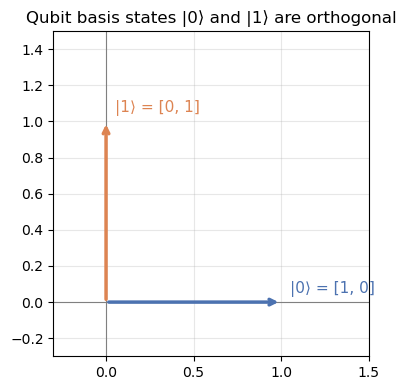

In [34]:
# Standard basis vectors for C² (qubit |0⟩ and |1⟩)
ket0 = np.array([1, 0], dtype=complex)   # |0⟩
ket1 = np.array([0, 1], dtype=complex)   # |1⟩

ip = inner_product(ket0, ket1)
print(f"⟨0|1⟩ = {ip}  → orthogonal: {np.isclose(ip, 0)}")

# Visualise
labels = ['|0⟩ = [1, 0]', '|1⟩ = [0, 1]']
colors = ['#4C72B0', '#DD8452']
fig, ax = plt.subplots(figsize=(4, 4))
for (label, vec, color) in zip(labels, [ket0, ket1], colors):
    ax.annotate('', xy=(vec[0].real, vec[1].real), xytext=(0,0),
                arrowprops=dict(arrowstyle='->', color=color, lw=2.5))
    ax.text(vec[0].real + 0.05, vec[1].real + 0.05, label, color=color, fontsize=11)
ax.set_xlim(-0.3, 1.5); ax.set_ylim(-0.3, 1.5)
ax.axhline(0, color='gray', lw=0.8); ax.axvline(0, color='gray', lw=0.8)
ax.set_title('Qubit basis states |0⟩ and |1⟩ are orthogonal')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


---
## 7. Hermitian Matrices — Measuring Quantum Systems

A matrix H is **Hermitian** if H† = H.

**Why it matters:**
1. All **eigenvalues are real** → measurements give real numbers (you can't measure a complex voltage!)
2. **Eigenvectors are orthogonal** → different outcomes are distinguishable
3. The **Spectral Theorem** guarantees a complete eigenbasis


In [35]:
# Build a Hermitian matrix
H = np.array([[2,    1+1j],
              [1-1j, 3   ]], dtype=complex)

print("H =")
show("H", H)
print("H† == H ?", np.allclose(H.conj().T, H))
print()

# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(H)   # eigh = for Hermitian matrices

print("Eigenvalues:", np.round(eigenvalues, 4))
print("→ All real?", np.allclose(eigenvalues.imag, 0))
print()
print("Eigenvectors (columns):")
show("Eigenvectors", np.round(eigenvectors, 4))


H =
────────────────────────────────────────
  H:
────────────────────────────────────────
         (2+0j)        (1+1j)
         (1-1j)        (3+0j)

H† == H ? True

Eigenvalues: [1. 4.]
→ All real? True

Eigenvectors (columns):
────────────────────────────────────────
  Eigenvectors:
────────────────────────────────────────
   (-0.8165-0j)  (-0.5774+0j)
   (0.4082-0.4082j)  (-0.5774+0.5774j)



In [36]:
# Verify eigenvectors are orthogonal
v0 = eigenvectors[:, 0]
v1 = eigenvectors[:, 1]

ip = inner_product(v0, v1)
print(f"⟨eigenvector0, eigenvector1⟩ = {np.round(ip, 10)}")
print(f"Orthogonal? {np.isclose(ip, 0)}")


⟨eigenvector0, eigenvector1⟩ = -0j
Orthogonal? True


---
## 8. Unitary Matrices — Quantum Gates

A matrix U is **Unitary** if U · U† = U† · U = I.

**What this means:**
- U is **reversible** — U† undoes what U did
- U **preserves norms** — valid states stay valid
- U **preserves inner products** — probabilities are conserved
- All quantum operations (except measurement) are unitary


In [37]:
# The Hadamard gate — creates superposition from |0⟩ or |1⟩
H_gate = (1/np.sqrt(2)) * np.array([[1,  1],
                                      [1, -1]], dtype=complex)

ket0 = np.array([1, 0], dtype=complex)
ket1 = np.array([0, 1], dtype=complex)

superpos_from_0 = H_gate @ ket0
superpos_from_1 = H_gate @ ket1

print("Hadamard gate H:")
show("H", np.round(H_gate, 4))

print(f"H|0⟩ = {np.round(superpos_from_0, 4)}  → equal chance of 0 or 1")
print(f"H|1⟩ = {np.round(superpos_from_1, 4)}  → equal chance of 0 or 1")
print()
print("Norm preserved?")
print(f"  |H|0⟩| = {np.round(np.linalg.norm(superpos_from_0), 4)}")
print(f"  |H|1⟩| = {np.round(np.linalg.norm(superpos_from_1), 4)}")


Hadamard gate H:
────────────────────────────────────────
  H:
────────────────────────────────────────
    (0.7071+0j)   (0.7071+0j)
    (0.7071+0j)  (-0.7071+0j)

H|0⟩ = [0.7071+0.j 0.7071+0.j]  → equal chance of 0 or 1
H|1⟩ = [ 0.7071+0.j -0.7071+0.j]  → equal chance of 0 or 1

Norm preserved?
  |H|0⟩| = 1.0
  |H|1⟩| = 1.0


In [38]:
# Show that H† undoes H (reversibility)
state = H_gate @ ket0               # apply Hadamard
recovered = H_gate.conj().T @ state # apply Hadamard† to undo

print("Start:    |0⟩ =", ket0)
print("After H:       =", np.round(state, 4))
print("After H†:      =", np.round(recovered, 4), "← back to |0⟩ ✓")


Start:    |0⟩ = [1.+0.j 0.+0.j]
After H:       = [0.7071+0.j 0.7071+0.j]
After H†:      = [1.+0.j 0.+0.j] ← back to |0⟩ ✓


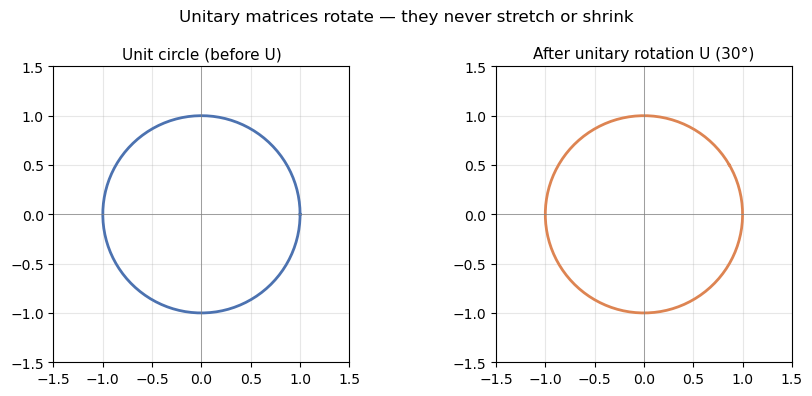

In [39]:
# Visualise: what unitary does to the unit circle (2D real case)
theta = np.pi / 6   # 30° rotation
U_rot = np.array([[np.cos(theta), -np.sin(theta)],
                   [np.sin(theta),  np.cos(theta)]])

angles = np.linspace(0, 2*np.pi, 200)
circle = np.array([np.cos(angles), np.sin(angles)])
rotated = U_rot @ circle

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, data, title, color in zip(axes,
    [circle, rotated],
    ['Unit circle (before U)', 'After unitary rotation U (30°)'],
    ['#4C72B0', '#DD8452']):
    ax.plot(data[0], data[1], color=color, lw=2)
    ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
    ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
    ax.set_aspect('equal'); ax.set_title(title, fontsize=11)
    ax.grid(True, alpha=0.3)
plt.suptitle("Unitary matrices rotate — they never stretch or shrink", fontsize=12)
plt.tight_layout(); plt.show()


---
## 9. Tensor Products & Entanglement

The **tensor product** (⊗) combines two quantum systems into one larger system.

$$C^m \otimes C^n = C^{mn}$$

- 1 qubit lives in C² (dimension 2)  
- 2 qubits live in C² ⊗ C² = C⁴ (dimension 4)  
- 3 qubits live in C⁸ (dimension 8)  
- n qubits → dimension **2ⁿ** — grows exponentially!

This exponential growth is why quantum computers can be so powerful.


In [40]:
# Tensor product of two vectors using np.kron (Kronecker product)
def tensor(v1, v2):
    return np.kron(v1, v2)

# Two single-qubit states
V = np.array([2, 3], dtype=complex)
W = np.array([4, 6, 3], dtype=complex)

VW = tensor(V, W)
print("V =", V, "  (lives in C²)")
print("W =", W, "  (lives in C³)")
print()
print("V ⊗ W =", VW, "  (lives in C⁶)")
print()
print("Manual check: entries are 2×[4,6,3] then 3×[4,6,3]")
print("  2×4=8, 2×6=12, 2×3=6, 3×4=12, 3×6=18, 3×3=9")


V = [2.+0.j 3.+0.j]   (lives in C²)
W = [4.+0.j 6.+0.j 3.+0.j]   (lives in C³)

V ⊗ W = [ 8.+0.j 12.+0.j  6.+0.j 12.+0.j 18.+0.j  9.+0.j]   (lives in C⁶)

Manual check: entries are 2×[4,6,3] then 3×[4,6,3]
  2×4=8, 2×6=12, 2×3=6, 3×4=12, 3×6=18, 3×3=9


In [41]:
# Entanglement: a state that CANNOT be written as a tensor of two vectors
# Bell state (maximally entangled)
bell = (1/np.sqrt(2)) * np.array([1, 0, 0, 1], dtype=complex)

print("Bell state |Φ+⟩ =", np.round(bell, 4))
print("Norm =", np.round(np.linalg.norm(bell), 4))
print()
print("This state CANNOT be written as v ⊗ w for any single-qubit v, w.")
print("The two qubits are ENTANGLED — measuring one instantly determines the other!")


Bell state |Φ+⟩ = [0.7071+0.j 0.    +0.j 0.    +0.j 0.7071+0.j]
Norm = 1.0

This state CANNOT be written as v ⊗ w for any single-qubit v, w.
The two qubits are ENTANGLED — measuring one instantly determines the other!


In [42]:
# Tensor product of matrices (quantum gates on multi-qubit systems)
X = np.array([[0, 1], [1, 0]], dtype=complex)   # NOT gate
I = np.eye(2, dtype=complex)                     # Identity gate

# X ⊗ I = apply X to qubit 1, do nothing to qubit 2
XI = np.kron(X, I)
# I ⊗ X = do nothing to qubit 1, apply X to qubit 2
IX = np.kron(I, X)

print("X ⊗ I (NOT first qubit):")
show("X ⊗ I", XI.real.astype(int))
print("I ⊗ X (NOT second qubit):")
show("I ⊗ X", IX.real.astype(int))


X ⊗ I (NOT first qubit):
────────────────────────────────────────
  X ⊗ I:
────────────────────────────────────────
              0             0             1             0
              0             0             0             1
              1             0             0             0
              0             1             0             0

I ⊗ X (NOT second qubit):
────────────────────────────────────────
  I ⊗ X:
────────────────────────────────────────
              0             1             0             0
              1             0             0             0
              0             0             0             1
              0             0             1             0



---
## 10. 🏋️ Mini Exercises

Try these yourself! Remove the `# YOUR CODE HERE` comment and write your solution. Check answers by running the assertion at the end of each cell.


### Exercise 1 — Vector Addition
Add V and W to get their sum.

In [43]:
V = np.array([5 + 13j,  6 + 2j, 0.53 - 6j, 12], dtype=complex)
W = np.array([7 -  8j,  4j,     2 + 0j,    9.4 + 3j], dtype=complex)

# YOUR CODE HERE
result = None

# Expected answer
expected = np.array([12+5j, 6+6j, 2.53-6j, 21.4+3j])
if result is not None:
    print("Your answer:", result)
    print("Correct?", np.allclose(result, expected))
else:
    print("👉 Replace None with your calculation!")


👉 Replace None with your calculation!


### Exercise 2 — Scalar Multiplication
Multiply V by the scalar `8 − 2j`.

In [44]:
c = 8 - 2j
V = np.array([16 + 2.3j, -7j, 6 + 0j, 5 - 4j], dtype=complex)

# YOUR CODE HERE
result = None

expected = c * V
if result is not None:
    print("Your answer:", result)
    print("Correct?", np.allclose(result, expected))
else:
    print("👉 Replace None with your calculation!")


👉 Replace None with your calculation!


### Exercise 3 — Adjoint
Compute the adjoint (A†) of matrix A.

In [45]:
A = np.array([[6 - 3j,  2 + 12j, -19j],
              [0,       5 + 2.1j, 17  ],
              [1,       2 + 5j,   3 - 4.5j]], dtype=complex)

# YOUR CODE HERE
A_adjoint = None

if A_adjoint is not None:
    print("Your A†:")
    show("A†", A_adjoint)
    print("Correct?", np.allclose(A_adjoint, A.conj().T))
else:
    print("👉 Replace None with your calculation! Hint: use .conj().T")


👉 Replace None with your calculation! Hint: use .conj().T


### Exercise 4 — Inner Product
Compute ⟨V₁, V₂⟩ for the vectors below.

In [46]:
V1 = np.array([2, 1, 3], dtype=complex)
V2 = np.array([6, 2, 4], dtype=complex)

# YOUR CODE HERE
result = None

expected = V1.conj() @ V2
if result is not None:
    print("⟨V1, V2⟩ =", result)
    print("Correct?", np.allclose(result, expected))
else:
    print("👉 Replace None with your calculation! Hint: use inner_product(V1, V2)")


👉 Replace None with your calculation! Hint: use inner_product(V1, V2)


### Exercise 5 — Check if a Matrix is Unitary
Write a function that returns `True` if a matrix is unitary.

In [47]:
def is_unitary(M):
    # YOUR CODE HERE
    # Hint: check if M @ M† ≈ identity matrix
    pass

# Test cases
H_gate = (1/np.sqrt(2)) * np.array([[1, 1], [1, -1]], dtype=complex)
random_M = np.array([[1, 2], [3, 4]], dtype=complex)

if is_unitary(H_gate) is not None:
    print("Hadamard unitary?", is_unitary(H_gate))   # should be True
    print("Random M unitary?", is_unitary(random_M))  # should be False
else:
    print("👉 Complete the is_unitary function!")


👉 Complete the is_unitary function!


---
## 📋 Summary Table

| Concept | Definition | Quantum Role |
|---------|-----------|--------------|
| **Complex vector** | List of complex numbers | Quantum state |
| **Vector addition** | Add entry by entry | Superposition |
| **Scalar multiplication** | Multiply all entries by c | Amplitude scaling |
| **Transpose Aᵀ** | Flip rows↔columns | Building adjoint |
| **Conjugate Ā** | Flip imaginary signs | Building adjoint |
| **Adjoint A†** | Transpose + conjugate | Core quantum operation |
| **Hermitian H† = H** | Self-adjoint matrix | Observable / measurement |
| **Unitary U·U† = I** | Preserves norms | Quantum gate |
| **Inner product ⟨v,w⟩** | v†·w → scalar | Probability amplitudes |
| **Norm \|V\|** | √⟨V,V⟩ | State normalisation |
| **Tensor product V⊗W** | Combine systems | Multi-qubit states |
| **Entanglement** | Non-separable tensor state | Quantum advantage |

---
*MSE Programme · Complex Vector Spaces · May 2026*  
*Based on Chapter 2: Quantum Computing — A Gentle Introduction*
